<a href="https://colab.research.google.com/github/AB0219/part-3-nlp-sequence-modeling/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import files
uploaded = files.upload()



Saving customer_support_text_classification.csv to customer_support_text_classification.csv


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

  ticket_id channel                                   customer_message  \
0  TKT00001    chat  I need information about the payment process. ...   
1  TKT00002   phone      I need information about the payment process.   
2  TKT00003   email  The refund process was fast and convenient. I ...   
3  TKT00004  social  My refund is still pending and this experience...   
4  TKT00005    chat   Please tell me how to update my account details.   

  sentiment_label  word_count  urgent_flag  
0         neutral          18            1  
1         neutral           7            0  
2        positive          12            0  
3        negative          15            1  
4         neutral           9            0  

Dataset Shape:
(1500, 6)

Number of Records:
1500

Target Classes:
['neutral' 'positive' 'negative']

Class Distribution:
sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64

Average Text Length:
12.722666666666667

Sample Messages:
0    I need i

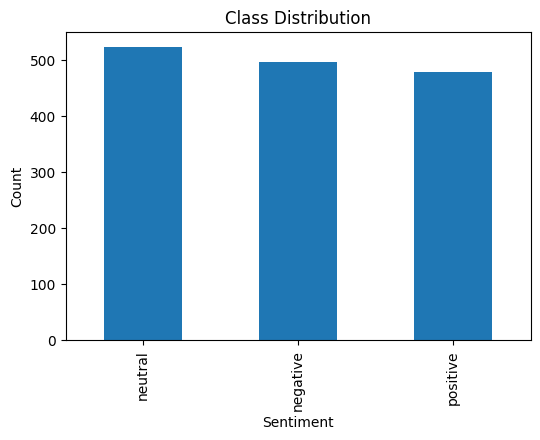

In [12]:
df = pd.read_csv("customer_support_text_classification.csv")

print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nNumber of Records:")
print(len(df))


print("\nTarget Classes:")
print(df['sentiment_label'].unique())


print("\nClass Distribution:")
print(df['sentiment_label'].value_counts())


df['text_length'] = df['customer_message'].apply(
    lambda x: len(str(x).split())
)

print("\nAverage Text Length:")
print(df['text_length'].mean())


print("\nSample Messages:")
print(df['customer_message'].head())


plt.figure(figsize=(6,4))

df['sentiment_label'].value_counts().plot(
    kind='bar'
)

plt.title("Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

In [18]:
import re
import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    tokens = word_tokenize(text)

    tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    return " ".join(tokens)
df['clean_text'] = df['customer_message'].apply(clean_text)

print(df[['customer_message', 'clean_text']].head())

                                    customer_message  \
0  I need information about the payment process. ...   
1      I need information about the payment process.   
2  The refund process was fast and convenient. I ...   
3  My refund is still pending and this experience...   
4   Please tell me how to update my account details.   

                                          clean_text  
0  need information payment process ticket number...  
1                   need information payment process  
2  refund process fast convenient appreciate quic...  
3  refund still pending experience frustrating ti...  
4                 please tell update account details  


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer


tfidf = TfidfVectorizer(max_features=5000)


X_tfidf = tfidf.fit_transform(df['clean_text'])


y = df['sentiment_label']

print("TF-IDF Shape:")
print(X_tfidf.shape)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


tokenizer = Tokenizer(num_words=5000)


tokenizer.fit_on_texts(df['clean_text'])


sequences = tokenizer.texts_to_sequences(
    df['clean_text']
)


X_seq = pad_sequences(
    sequences,
    maxlen=100,
    padding='post',
    truncating='post'
)

print("Sequence Shape:")
print(X_seq.shape)

TF-IDF Shape:
(1500, 146)
Sequence Shape:
(1500, 100)


Accuracy:
1.0

Classification Report:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       109
     neutral       1.00      1.00      1.00       104
    positive       1.00      1.00      1.00        87

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



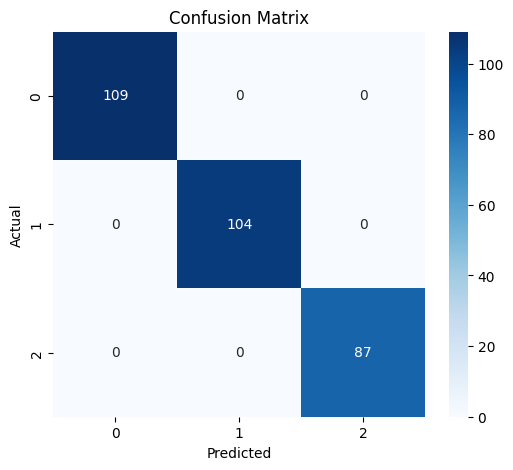

Evaluation metrics saved.
Sample predictions saved.


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt
import os

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42
)


model = LogisticRegression()


model.fit(X_train, y_train)


y_pred = model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:")
print(accuracy)


print("\nClassification Report:")
print(classification_report(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred)


plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")


os.makedirs('results', exist_ok=True)
plt.savefig("results/model_evaluation.png")

plt.show()

metrics_df = pd.DataFrame({
    'Metric': ['Accuracy'],
    'Value': [accuracy]
})

metrics_df.to_csv(
    "model_evaluation.csv",
    index=False
)

print("Evaluation metrics saved.")

sample_df = pd.DataFrame({
    'Message': X_test[:10].shape[0] * ['Sample Message'],
    'Actual': y_test.iloc[:10].values,
    'Predicted': y_pred[:10]
})

with open("sample_predictions.txt", "w") as f:

    for i in range(10):

        f.write(
            f"Actual: {sample_df['Actual'][i]}\n"
        )

        f.write(
            f"Predicted: {sample_df['Predicted'][i]}\n\n"
        )

print("Sample predictions saved.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 137ms/step - accuracy: 0.3708 - loss: 1.0976 - val_accuracy: 0.3292 - val_loss: 1.1047
Epoch 2/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - accuracy: 0.3552 - loss: 1.1001 - val_accuracy: 0.3292 - val_loss: 1.1002
Epoch 3/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - accuracy: 0.3365 - loss: 1.0999 - val_accuracy: 0.3292 - val_loss: 1.0998
Epoch 4/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.3552 - loss: 1.0983 - val_accuracy: 0.3292 - val_loss: 1.1005
Epoch 5/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.3552 - loss: 1.0983 - val_accuracy: 0.3292 - val_loss: 1.0995
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3467 - loss: 1.0977
Test Accuracy: 0.3466666638851166


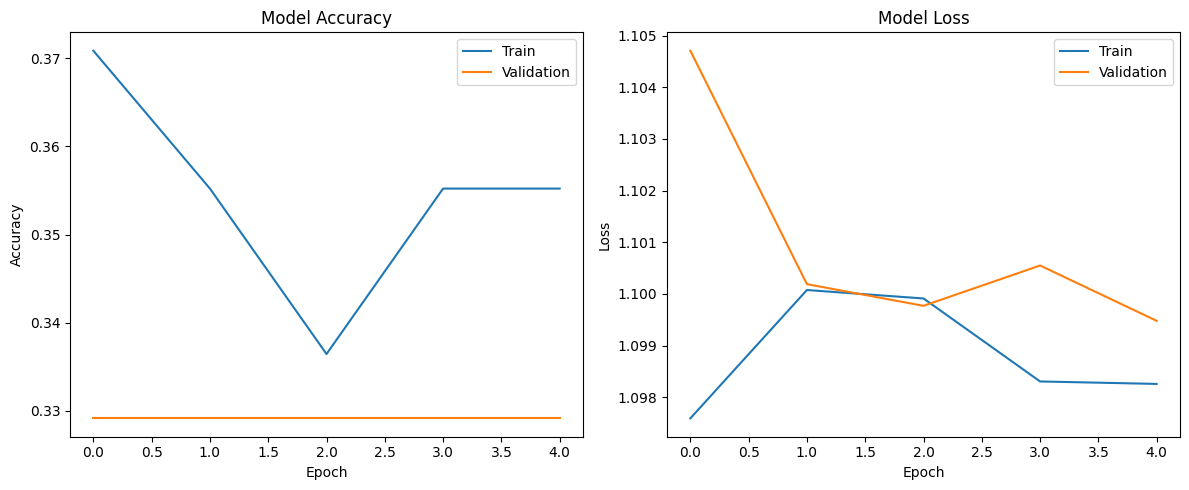

In [28]:
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense
)

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq,
    y_encoded,
    test_size=0.2,
    random_state=42
)

lstm_model = Sequential([

    Embedding(
        input_dim=5000,
        output_dim=128,
        input_length=100
    ),

    LSTM(64),

    Dense(3, activation='softmax')
])

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

history = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

loss, accuracy = lstm_model.evaluate(
    X_test_seq,
    y_test_seq
)

print("Test Accuracy:", accuracy)


plt.figure(figsize=(12,5))


plt.subplot(1,2,1)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(['Train', 'Validation'])


plt.subplot(1,2,2)

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(['Train', 'Validation'])

plt.tight_layout()

plt.savefig("lstm_training_curves.png")

plt.show()

In [27]:
reflection = """

1. Why RNNs struggle with long-term dependencies:
RNNs process data sequentially, but information from earlier
time steps gradually fades as the sequence becomes longer.
This causes the vanishing gradient problem.

2. How LSTMs help:
LSTMs introduce memory cells and gates that help preserve
important information over long sequences.

3. What attention solves:
Attention allows the model to focus on important words
instead of compressing the entire sentence into one vector.

4. Why transformers are important:
Transformers use self-attention and parallel processing,
making them highly efficient and powerful for modern NLP
and Generative AI applications.

"""

print(reflection)



1. Why RNNs struggle with long-term dependencies:
RNNs process data sequentially, but information from earlier
time steps gradually fades as the sequence becomes longer.
This causes the vanishing gradient problem.

2. How LSTMs help:
LSTMs introduce memory cells and gates that help preserve
important information over long sequences.

3. What attention solves:
Attention allows the model to focus on important words
instead of compressing the entire sentence into one vector.

4. Why transformers are important:
Transformers use self-attention and parallel processing,
making them highly efficient and powerful for modern NLP
and Generative AI applications.




  ticket_id channel                                   customer_message  \
0  TKT00001    chat  I need information about the payment process. ...   
1  TKT00002   phone      I need information about the payment process.   
2  TKT00003   email  The refund process was fast and convenient. I ...   
3  TKT00004  social  My refund is still pending and this experience...   
4  TKT00005    chat   Please tell me how to update my account details.   

  sentiment_label  word_count  urgent_flag  
0         neutral          18            1  
1         neutral           7            0  
2        positive          12            0  
3        negative          15            1  
4         neutral           9            0  

Dataset Shape:
(1500, 6)

Number of Records:
1500

Target Classes:
['neutral' 'positive' 'negative']

Class Distribution:
sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64

Average Text Length:
12.722666666666667

Sample Messages:
0    I need i

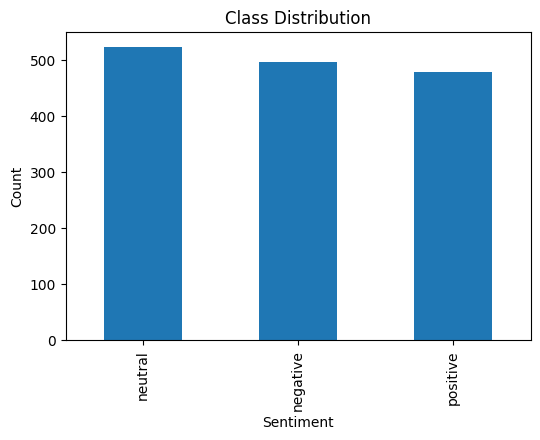

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


                                    customer_message  \
0  I need information about the payment process. ...   
1      I need information about the payment process.   
2  The refund process was fast and convenient. I ...   
3  My refund is still pending and this experience...   
4   Please tell me how to update my account details.   

                                          clean_text  
0  need information payment process ticket number...  
1                   need information payment process  
2  refund process fast convenient appreciate quic...  
3  refund still pending experience frustrating ti...  
4                 please tell update account details  
TF-IDF Shape:
(1500, 146)
Sequence Shape:
(1500, 100)
TF-IDF Shape:
(1500, 146)
Sequence Shape:
(1500, 100)


WHY TEXT IS CONVERTED INTO VECTORS:

Machine learning models cannot understand raw text directly.

Models perform mathematical operations using numbers.

TF-IDF converts words into weighted numerical values.

Tokenizer sequ

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - accuracy: 0.3177 - loss: 1.1038 - val_accuracy: 0.3292 - val_loss: 1.1015
Epoch 2/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.3552 - loss: 1.0988 - val_accuracy: 0.3292 - val_loss: 1.1004
Epoch 3/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - accuracy: 0.3552 - loss: 1.0993 - val_accuracy: 0.3292 - val_loss: 1.0998
Epoch 4/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.3552 - loss: 1.0991 - val_accuracy: 0.3292 - val_loss: 1.0995
Epoch 5/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.3552 - loss: 1.0981 - val_accuracy: 0.3292 - val_loss: 1.0996
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3467 - loss: 1.0986

LSTM Test Accuracy:
0.3466666638851166


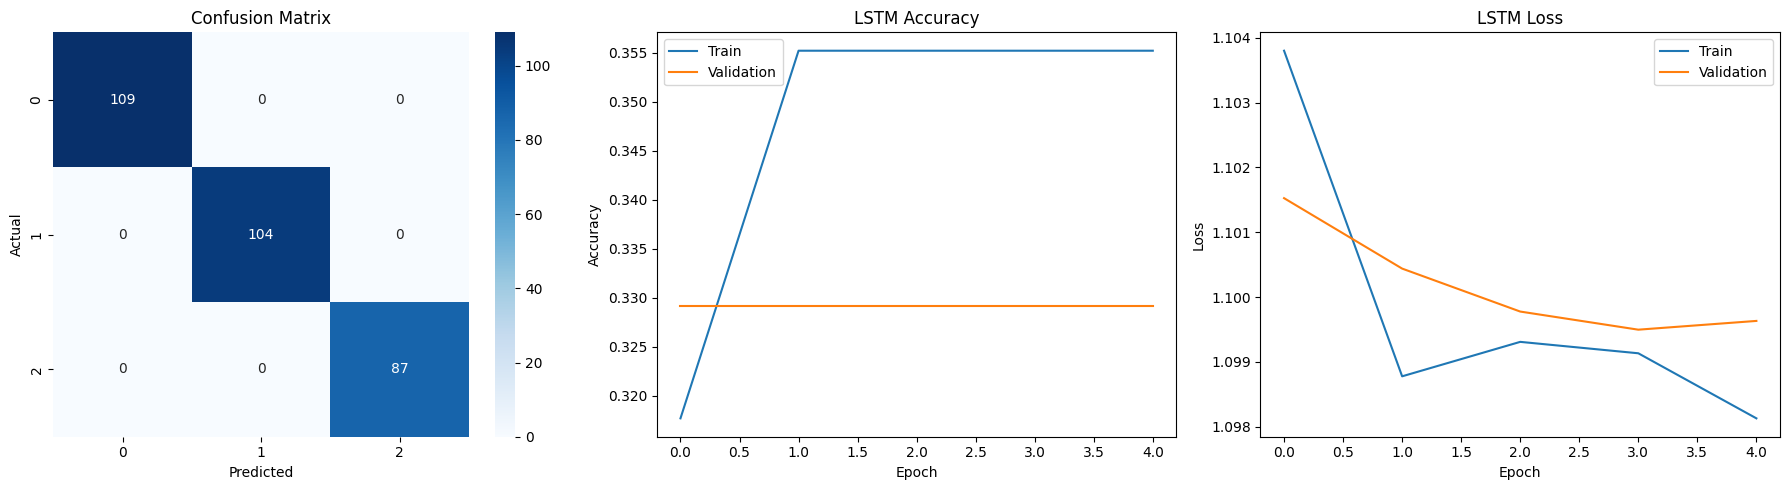


Combined evaluation image saved successfully.
Metrics CSV saved successfully.
Sample predictions saved successfully.


1. Why RNNs struggle with long-term dependencies:
RNNs process data sequentially, but information from earlier
time steps gradually fades as the sequence becomes longer.
This causes the vanishing gradient problem.

2. How LSTMs help:
LSTMs introduce memory cells and gates that help preserve
important information over long sequences.

3. What attention solves:
Attention allows the model to focus on important words
instead of compressing the entire sentence into one vector.

4. Why transformers are important:
Transformers use self-attention and parallel processing,
making them highly efficient and powerful for modern NLP
and Generative AI applications.




In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("customer_support_text_classification.csv")

print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nNumber of Records:")
print(len(df))

print("\nTarget Classes:")
print(df['sentiment_label'].unique())

print("\nClass Distribution:")
print(df['sentiment_label'].value_counts())

df['text_length'] = df['customer_message'].apply(
    lambda x: len(str(x).split())
)

print("\nAverage Text Length:")
print(df['text_length'].mean())

print("\nSample Messages:")
print(df['customer_message'].head())

plt.figure(figsize=(6,4))

df['sentiment_label'].value_counts().plot(
    kind='bar'
)

plt.title("Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()







import re
import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    tokens = word_tokenize(text)

    tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    return " ".join(tokens)
df['clean_text'] = df['customer_message'].apply(clean_text)

print(df[['customer_message', 'clean_text']].head())





from sklearn.feature_extraction.text import TfidfVectorizer


tfidf = TfidfVectorizer(max_features=5000)


X_tfidf = tfidf.fit_transform(df['clean_text'])


y = df['sentiment_label']

print("TF-IDF Shape:")
print(X_tfidf.shape)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


tokenizer = Tokenizer(num_words=5000)


tokenizer.fit_on_texts(df['clean_text'])


sequences = tokenizer.texts_to_sequences(
    df['clean_text']
)


X_seq = pad_sequences(
    sequences,
    maxlen=100,
    padding='post',
    truncating='post'
)

print("Sequence Shape:")
print(X_seq.shape)




import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense
)


tfidf = TfidfVectorizer(max_features=5000)

X_tfidf = tfidf.fit_transform(df['clean_text'])

y = df['sentiment_label']

print("TF-IDF Shape:")
print(X_tfidf.shape)


tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(df['clean_text'])

sequences = tokenizer.texts_to_sequences(
    df['clean_text']
)

X_seq = pad_sequences(
    sequences,
    maxlen=100,
    padding='post',
    truncating='post'
)

print("Sequence Shape:")
print(X_seq.shape)


print("""

WHY TEXT IS CONVERTED INTO VECTORS:

Machine learning models cannot understand raw text directly.

Models perform mathematical operations using numbers.

TF-IDF converts words into weighted numerical values.

Tokenizer sequences convert words into integer IDs,
which are used in sequence models such as:
- RNN
- LSTM
- GRU

""")


X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42
)

baseline_model = LogisticRegression()

baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)

baseline_accuracy = accuracy_score(y_test, y_pred)

print("Baseline Model Accuracy:")
print(baseline_accuracy)

print("\nClassification Report:\n")

print(classification_report(
    y_test,
    y_pred
))


encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

# Train-test split for sequence model
X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq,
    y_encoded,
    test_size=0.2,
    random_state=42
)

lstm_model = Sequential([

    Embedding(
        input_dim=5000,
        output_dim=128,
        input_length=100
    ),

    LSTM(64),

    Dense(3, activation='softmax')
])

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

history = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

loss, lstm_accuracy = lstm_model.evaluate(
    X_test_seq,
    y_test_seq
)

print("\nLSTM Test Accuracy:")
print(lstm_accuracy)


cm = confusion_matrix(y_test, y_pred)


plt.figure(figsize=(18,5))


plt.subplot(1,3,1)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")


plt.subplot(1,3,2)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("LSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(['Train', 'Validation'])


plt.subplot(1,3,3)

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("LSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(['Train', 'Validation'])


plt.tight_layout()

plt.savefig(
    "model_evaluation.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("\nCombined evaluation image saved successfully.")


metrics_df = pd.DataFrame({

    'Metric': [
        'Baseline Accuracy',
        'LSTM Accuracy'
    ],

    'Value': [
        baseline_accuracy,
        lstm_accuracy
    ]
})

metrics_df.to_csv(
    "model_evaluation.csv",
    index=False
)

print("Metrics CSV saved successfully.")


sample_predictions = pd.DataFrame({

    'Actual': y_test.iloc[:10].values,
    'Predicted': y_pred[:10]
})

with open("sample_predictions.txt", "w") as f:

    for i in range(len(sample_predictions)):

        f.write(
            f"Actual: {sample_predictions['Actual'][i]}\n"
        )

        f.write(
            f"Predicted: {sample_predictions['Predicted'][i]}\n\n"
        )

print("Sample predictions saved successfully.")


#task 5



reflection = """

1. Why RNNs struggle with long-term dependencies:
RNNs process data sequentially, but information from earlier
time steps gradually fades as the sequence becomes longer.
This causes the vanishing gradient problem.

2. How LSTMs help:
LSTMs introduce memory cells and gates that help preserve
important information over long sequences.

3. What attention solves:
Attention allows the model to focus on important words
instead of compressing the entire sentence into one vector.

4. Why transformers are important:
Transformers use self-attention and parallel processing,
making them highly efficient and powerful for modern NLP
and Generative AI applications.

"""

print(reflection)